# U.S. Electricity Revenue Analysis

## Google Data Analytics Case Study

This notebook follows the six phases used in the Google Data Analytics Professional Certificate:

1. **Ask** — define the business task and key questions  
2. **Prepare** — understand the source, structure, and limitations of the data  
3. **Process** — clean, validate, and transform the data  
4. **Analyze** — calculate trends and comparisons  
5. **Share** — communicate findings with clear visualizations  
6. **Act** — summarize conclusions and recommend next steps  

> **Important:** The dataset contains U.S. states as well as regional and national aggregate rows. It also contains an `all sectors` category alongside individual sectors. These must be handled carefully to avoid double-counting.

# 1. Ask

## Business task

Analyze how reported U.S. electricity revenue has changed over time and identify which states contribute the most revenue.

## Stakeholder questions

- What years are covered by the dataset?
- Is every year complete?
- How has annual electricity revenue changed?
- Which states have the highest cumulative revenue?
- How do annual revenue trends differ among the top ten states?

## Scope

This is an exploratory case study. It does not attempt to establish causation or produce a production-grade forecast.

# 2. Prepare

## Data source

The analysis uses a cleaned CSV file containing annual/monthly electricity observations by location and sector. Source : Kaggle : US_electricity_prices

Expected columns include:

- `year`
- `month`
- `stateDescription`
- `sectorName`
- `customers`
- `price`
- `revenue`



In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Update this path only if your file moves.
file_path = Path(
    r"C:\Users\nevez\OneDrive\Desktop\Data eng-analysis\clean_data"
    r"\clean_data_electricity_us.csv"
)

if not file_path.exists():
    raise FileNotFoundError(
        f"CSV file not found:\n{file_path}\n\n"
        "Update the file_path variable so it points to your local CSV file."
    )

df_raw = pd.read_csv(file_path)
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")
df_raw.head(10)

Loaded 85,870 rows and 8 columns.


,year,month,stateDescription,sectorName,customers,price,revenue,sales
0,2001,1,Wyoming,all sectors,NaN,4.31,48.13,"1,116.17"
1,2001,1,Wyoming,commercial,NaN,5.13,12.68,247.09
2,2001,1,Wyoming,industrial,NaN,3.26,19.61,602.30
3,2001,1,Wyoming,other,NaN,4.75,0.77,16.17
4,2001,1,Wyoming,residential,NaN,6.01,15.07,250.61
5,2001,1,New England,all sectors,NaN,10.73,"1,139.90","10,622.88"
6,2001,1,South Carolina,other,NaN,6.57,5.28,80.41
7,2001,1,South Carolina,residential,NaN,7.36,225.82,"3,066.26"
8,2001,1,South Dakota,all sectors,NaN,5.85,46.99,803.24
9,2001,1,South Dakota,commercial,NaN,5.95,15.92,267.66


## Initial inspection

Before changing the data, we inspect its dimensions, column names, data types, missing values, and duplicates.

In [4]:
print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

print("\nData types and non-null counts:")
df_raw.info()

print("\nMissing values:")
display(df_raw.isna().sum().sort_values(ascending=False))

print("\nExact duplicate rows:", df_raw.duplicated().sum())

Shape: (85870, 8)

Columns:
['year', 'month', 'stateDescription', 'sectorName', 'customers', 'price', 'revenue', 'sales']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85870 entries, 0 to 85869
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              85870 non-null  int64  
 1   month             85870 non-null  int64  
 2   stateDescription  85870 non-null  object 
 3   sectorName        85870 non-null  object 
 4   customers         59830 non-null  float64
 5   price             85870 non-null  float64
 6   revenue           85870 non-null  float64
 7   sales             85870 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 5.2+ MB

Missing values:


customers           26040
year                    0
month                   0
stateDescription        0
sectorName              0
price                   0
revenue                 0
sales                   0
dtype: int64


Exact duplicate rows: 0


In [5]:
print("Year range:", df_raw["year"].min(), "to", df_raw["year"].max())
print("Distinct location descriptions:", df_raw["stateDescription"].nunique())
print("Distinct sectors:", df_raw["sectorName"].nunique())

print("\nSector values:")
print(sorted(df_raw["sectorName"].dropna().unique()))

print("\nLocation descriptions:")
print(sorted(df_raw["stateDescription"].dropna().unique()))

Year range: 2001 to 2024
Distinct location descriptions: 62
Distinct sectors: 6

Sector values:
['all sectors', 'commercial', 'industrial', 'other', 'residential', 'transportation']

Location descriptions:
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'East North Central', 'East South Central', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Middle Atlantic', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Mountain', 'Nebraska', 'Nevada', 'New England', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pacific Contiguous', 'Pacific Noncontiguous', 'Pennsylvania', 'Rhode Island', 'South Atlantic', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'U.S. Total', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West North Central

## Preparation Notes

Before beginning the analysis, we took some time to better understand the structure of the dataset. During this exploration, we noticed that some columns contained more information than we initially expected, so we refined our approach before moving forward.

- **`stateDescription`** does not contain only U.S. states. It also includes the District of Columbia, census regions, divisions, and national aggregate entries. Since our objective is to compare states, we restrict the analysis to the individual states (and Washington, D.C., when appropriate).

- **`sectorName`** contains both individual sectors (Residential, Commercial, Industrial, Transportation, etc.) and an **All Sectors** category. Because the **All Sectors** records already represent the combined total across sectors, including them together with the individual sectors would result in double counting. To ensure consistent and accurate calculations, we use only the **All Sectors** records when analyzing total state revenue.

# 3. Process

## 3.1 Standardize column names and data types

In [6]:
df = df_raw.copy()

# Remove accidental spaces from column names.
df.columns = df.columns.str.strip()

required_columns = {
    "year", "month", "stateDescription", "sectorName",
    "customers", "price", "revenue"
}

missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

# Standardize text columns.
df["stateDescription"] = df["stateDescription"].astype("string").str.strip()
df["sectorName"] = df["sectorName"].astype("string").str.strip().str.lower()

# Convert analytical columns to numeric.
for column in ["year", "month", "customers", "price", "revenue"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.head()

,year,month,stateDescription,sectorName,customers,price,revenue,sales
0,2001,1,Wyoming,all sectors,NaN,4.31,48.13,"1,116.17"
1,2001,1,Wyoming,commercial,NaN,5.13,12.68,247.09
2,2001,1,Wyoming,industrial,NaN,3.26,19.61,602.30
3,2001,1,Wyoming,other,NaN,4.75,0.77,16.17
4,2001,1,Wyoming,residential,NaN,6.01,15.07,250.61


## 3.2 Validate records

We check for missing keys, impossible values, duplicate rows, and coverage by year.

In [7]:
quality_summary = pd.Series({
    "rows": len(df),
    "duplicate_rows": df.duplicated().sum(),
    "missing_year": df["year"].isna().sum(),
    "missing_month": df["month"].isna().sum(),
    "missing_location": df["stateDescription"].isna().sum(),
    "missing_sector": df["sectorName"].isna().sum(),
    "missing_revenue": df["revenue"].isna().sum(),
    "negative_revenue": (df["revenue"] < 0).sum(),
    "invalid_month": (~df["month"].between(1, 12)).sum()
})

quality_summary

rows                85870
duplicate_rows          0
missing_year            0
missing_month           0
missing_location        0
missing_sector          0
missing_revenue         0
negative_revenue        2
invalid_month           0
dtype: int64

In [8]:
# Remove exact duplicates only. Other issues should be investigated, not silently deleted.
df = df.drop_duplicates().copy()

coverage_by_year = (
    df.groupby("year")
      .agg(
          rows=("revenue", "size"),
          non_null_revenue=("revenue", "count"),
          months=("month", "nunique"),
          locations=("stateDescription", "nunique"),
          sectors=("sectorName", "nunique")
      )
)

coverage_by_year

,rows,non_null_revenue,months,locations,sectors
year,,,,,
2001,3720,3720,12,62,5
2002,3720,3720,12,62,5
2003,3720,3720,12,62,5
2004,3720,3720,12,62,5
2005,3720,3720,12,62,5
2006,3720,3720,12,62,5
2007,3720,3720,12,62,5
2008,3720,3720,12,62,5
2009,3720,3720,12,62,5


## 3.3 Define valid state-level observations

The following list contains the 50 states plus the District of Columbia. Regional and national aggregates are excluded.

For state revenue analysis, we also retain only `all sectors` rows to prevent double-counting across sector totals.

In [10]:
state_names = {
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "District of Columbia", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky",
    "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota",
    "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island",
    "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"
}

state_level = df[
    df["stateDescription"].isin(state_names)
    & df["sectorName"].eq("all sectors")
].copy()

print("State-level rows:", f"{len(state_level):,}")
print("Locations retained:", state_level["stateDescription"].nunique())
print("Years retained:", int(state_level["year"].min()), "to", int(state_level["year"].max()))

State-level rows: 14,127
Locations retained: 51
Years retained: 2001 to 2024


## 3.4 Investigate year completeness

A very low final-year value is not automatically a statistical outlier. It may represent partial-year data. We compare row, month, and state coverage before deciding whether to exclude it.

In [11]:
state_coverage_by_year = (
    state_level.groupby("year")
    .agg(
        total_revenue=("revenue", "sum"),
        rows=("revenue", "size"),
        months=("month", "nunique"),
        states=("stateDescription", "nunique")
    )
)

state_coverage_by_year.tail()

,total_revenue,rows,months,states
year,,,,
2020,"393,639.42",612,12,51
2021,"422,323.25",612,12,51
2022,"485,248.94",612,12,51
2023,"491,123.77",612,12,51
2024,"43,413.55",51,1,51


In [12]:
latest_year = int(state_level["year"].max())
latest_year_summary = state_coverage_by_year.loc[latest_year]

latest_year_complete = (
    latest_year_summary["months"] == 12
    and latest_year_summary["states"] == len(state_names)
)

print(f"Latest year: {latest_year}")
print(latest_year_summary)
print("\nAppears complete:", latest_year_complete)

Latest year: 2024
total_revenue   43,413.55
rows                51.00
months               1.00
states              51.00
Name: 2024, dtype: float64

Appears complete: False


### Analysis decision

The trend analysis below excludes the latest year **only when its coverage appears incomplete**. This is documented as a data-completeness decision, not as removal of a genuine extreme observation.

In [13]:
if latest_year_complete:
    analysis_end_year = latest_year
else:
    analysis_end_year = latest_year - 1

state_level_complete = state_level[state_level["year"] <= analysis_end_year].copy()

print(
    f"Trend-analysis period: "
    f"{int(state_level_complete['year'].min())}–{analysis_end_year}"
)

Trend-analysis period: 2001–2023


# 4. Analyze

## 4.1 Annual state-level revenue

This calculation sums `all sectors` revenue across the 50 states and District of Columbia for each year.

In [14]:
revenue_by_year = (
    state_level_complete.groupby("year")["revenue"]
    .sum()
    .sort_index()
)

revenue_by_year.to_frame("total_revenue").tail()

,total_revenue
year,
2019,"401,738.14"
2020,"393,639.42"
2021,"422,323.25"
2022,"485,248.94"
2023,"491,123.77"


## 4.2 Validate the aggregation

The sum of annual totals should equal the revenue sum in the filtered analytical dataset.

In [15]:
source_total = state_level_complete["revenue"].sum()
annual_total = revenue_by_year.sum()
difference = source_total - annual_total

print(f"Source total: {source_total:,.2f}")
print(f"Sum of annual totals: {annual_total:,.2f}")
print(f"Difference: {difference:,.10f}")

assert np.isclose(source_total, annual_total), "Aggregation validation failed."

Source total: 8,352,198.75
Sum of annual totals: 8,352,198.75
Difference: -0.0000000009


## 4.3 Plot annual revenue

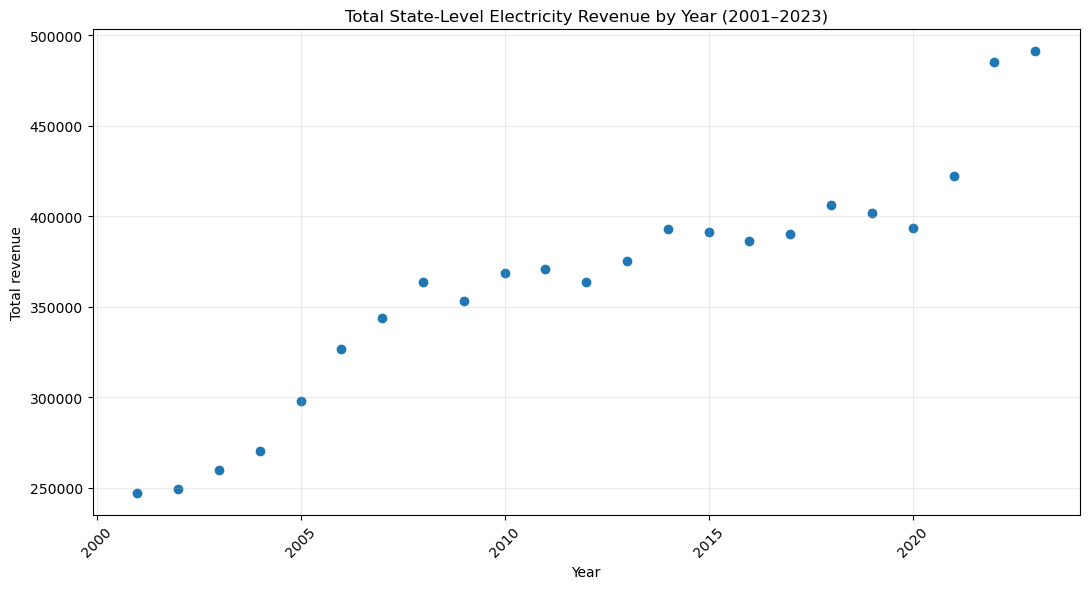

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(revenue_by_year.index, revenue_by_year.values)
ax.set(
    title=f"Total State-Level Electricity Revenue by Year ({int(revenue_by_year.index.min())}–{analysis_end_year})",
    xlabel="Year",
    ylabel="Total revenue"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4.4 Fit a linear trend

A first-degree polynomial is used as a descriptive summary of the long-term trend. It is not treated as a causal model or a forecast.

In [18]:
years = revenue_by_year.index.to_numpy(dtype=float)
revenues = revenue_by_year.to_numpy(dtype=float)

slope, intercept = np.polyfit(years, revenues, 1)
fitted_revenue = slope * years + intercept

residual_sum_squares = np.sum((revenues - fitted_revenue) ** 2)
total_sum_squares = np.sum((revenues - revenues.mean()) ** 2)
r_squared = 1 - residual_sum_squares / total_sum_squares

print(f"Estimated annual change: {slope:,.2f} revenue units per year")
print(f"R²: {r_squared:.3f}")

Estimated annual change: 9,079.15 revenue units per year
R²: 0.887


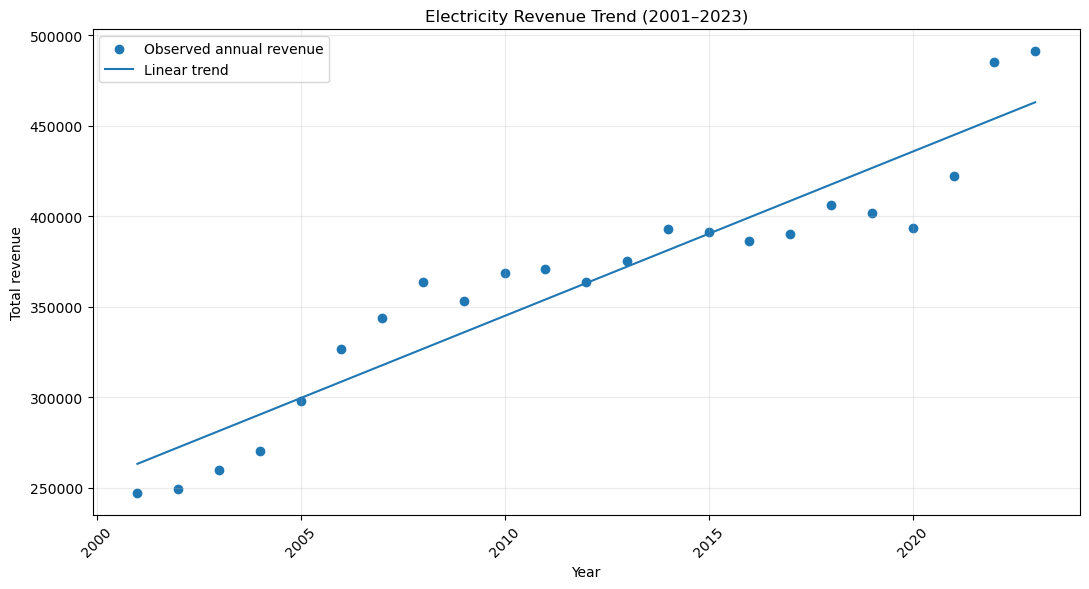

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(years, revenues, label="Observed annual revenue")
ax.plot(years, fitted_revenue, label="Linear trend")

ax.set(
    title=f"Electricity Revenue Trend ({int(years.min())}–{int(years.max())})",
    xlabel="Year",
    ylabel="Total revenue"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation template

Complete this statement after running the notebook:

> From **[first year]** through **[last complete year]**, state-level electricity revenue shows a generally **[increasing/decreasing]** trend. The fitted line estimates an average annual change of **[slope]** revenue units. The R² value of **[R²]** indicates that a linear trend explains **[weak/moderate/strong]** variation in annual revenue.

## 4.5 Top ten states by cumulative revenue

The ranking is based on cumulative revenue during the complete analysis period.

In [20]:
state_revenue = (
    state_level_complete.groupby("stateDescription")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top10_states = state_revenue.head(10)
top10_states.to_frame("cumulative_revenue")

,cumulative_revenue
stateDescription,
California,"872,897.06"
Texas,"780,404.22"
Florida,"538,570.84"
New York,"498,885.66"
Pennsylvania,"322,164.87"
Ohio,"308,245.70"
Illinois,"283,879.75"
Georgia,"277,719.87"
North Carolina,"258,156.68"


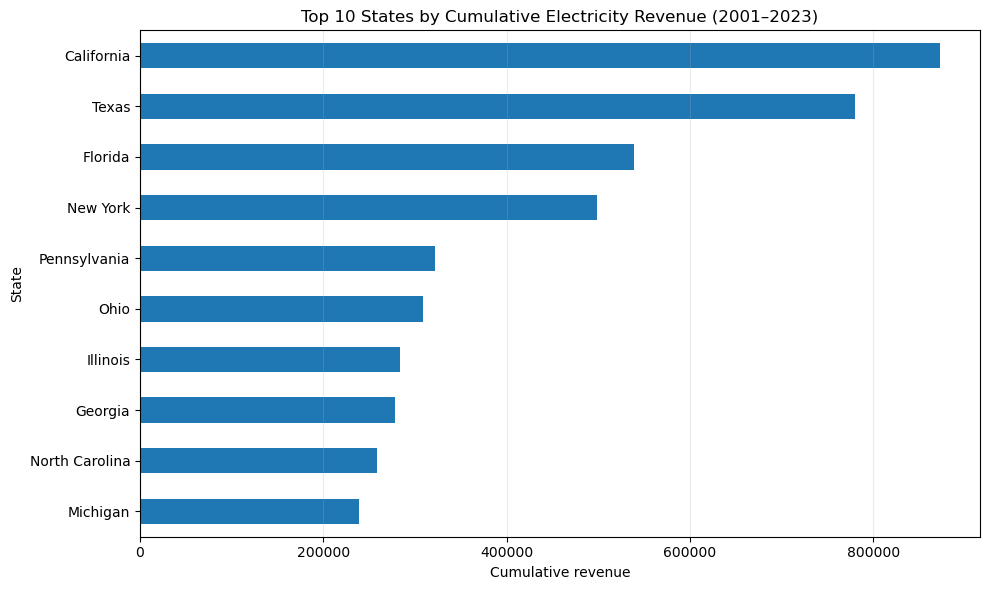

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_states.sort_values().plot(kind="barh", ax=ax)

ax.set(
    title=f"Top 10 States by Cumulative Electricity Revenue ({int(years.min())}–{analysis_end_year})",
    xlabel="Cumulative revenue",
    ylabel="State"
)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## 4.6 Annual revenue trends for the top ten states

In [22]:
top10_names = top10_states.index

top10_revenue_by_year = (
    state_level_complete[
        state_level_complete["stateDescription"].isin(top10_names)
    ]
    .groupby(["year", "stateDescription"])["revenue"]
    .sum()
    .unstack("stateDescription")
    .sort_index()
)

top10_revenue_by_year.tail()

stateDescription,California,Florida,Georgia,Illinois,Michigan,New York,North Carolina,Ohio,Pennsylvania,Texas
year,,,,,,,,,,
2019,"42,290.06","25,103.43","13,739.61","13,228.03","11,700.91","20,883.53","12,892.93","14,229.12","14,281.86","36,910.42"
2020,"45,028.61","24,394.22","13,247.09","12,915.10","11,846.54","20,872.15","12,293.46","13,459.73","13,549.24","35,705.76"
2021,"48,589.10","25,764.33","14,333.23","13,754.31","12,910.02","22,782.82","12,612.20","14,423.86","14,288.77","39,797.33"
2022,"56,243.93","31,129.15","17,406.36","16,223.48","13,286.36","26,245.82","13,363.39","15,906.23","17,209.23","48,285.04"
2023,"58,917.74","33,862.75","16,012.45","15,573.31","13,320.32","25,480.31","14,656.34","16,318.75","17,382.16","48,634.82"


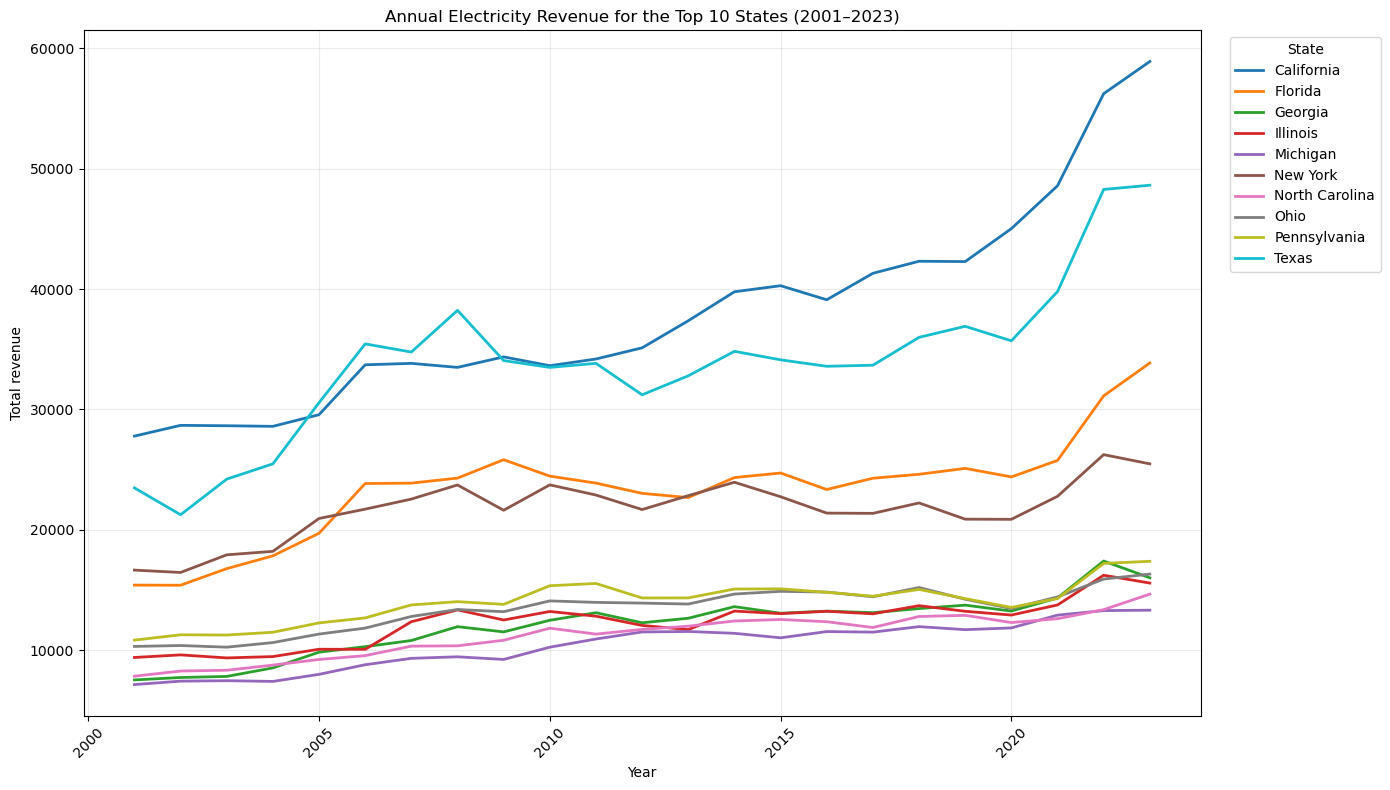

In [23]:
fig, ax = plt.subplots(figsize=(14, 8))

for state in top10_revenue_by_year.columns:
    ax.plot(
        top10_revenue_by_year.index,
        top10_revenue_by_year[state],
        linewidth=2,
        label=state
    )

ax.set(
    title=f"Annual Electricity Revenue for the Top 10 States ({int(years.min())}–{analysis_end_year})",
    xlabel="Year",
    ylabel="Total revenue"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)
ax.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# 5. Share

## Key findings

After running all cells, replace the placeholders below with evidence from the outputs.

1. **Data coverage:** The dataset spans **[start year]–[latest year]**, but **[latest year]** appears **[complete/incomplete]** based on month and state coverage.
2. **Revenue trend:** Revenue generally **[rose/fell/remained stable]** during the complete analysis period.
3. **Linear trend:** The fitted slope was **[value]** revenue units per year, with an R² of **[value]**.
4. **State ranking:** The three states with the highest cumulative revenue were **[state 1]**, **[state 2]**, and **[state 3]**.
5. **Important limitation:** Regional/national aggregates and duplicated sector totals were excluded to prevent inflated totals.

## Communication notes

- Use titles that state what each chart shows.
- Label units clearly after confirming the dataset's revenue unit.
- Explain why the incomplete final year was excluded.
- Avoid claiming that the trend line proves a cause-and-effect relationship.

# 6. Act

## Recommended next steps

- Confirm the official unit used for the `revenue` field from the dataset documentation.
- Investigate why the latest year is incomplete and update the analysis when full data becomes available.
- Compare residential, commercial, and industrial sectors separately.
- Analyze price and sales alongside revenue to understand what may be driving changes.
- Add inflation-adjusted revenue if the goal is to compare economic value across many years.
- Build a small dashboard with filters for year, state, and sector.

## Final conclusion

This case study provides a reproducible starting point for analyzing U.S. electricity revenue. The strongest methodological improvement is separating true state-level observations from regional aggregates and avoiding double-counting caused by combining `all sectors` with its component sectors.